In [ ]:
import multiprocessing
from multiprocessing.pool import ThreadPool
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from tqdm import tqdm
from prettytable import PrettyTable
import pickle
import os
os.chdir(r"C:\Users\Sannidhi Hegde\Downloads\aptos2019-blindness-detection")
print('CWD is', os.getcwd())

from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["axes.grid"] = False

from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
import keras
from keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img
from keras import optimizers, Model, Sequential
from keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, Activation
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
def load_data():
    train = pd.read_csv('train.csv')
    test = pd.read_csv('test.csv')

    train_dir = os.path.join('.', 'train_images/')
    test_dir = os.path.join('.', 'test_images/')

    train['file_path'] = train['id_code'].map(lambda x: os.path.join(train_dir, f'{x}.png'))
    test['file_path'] = test['id_code'].map(lambda x: os.path.join(test_dir, f'{x}.png'))

    train['file_name'] = train['id_code'].map(lambda x: f"{x}.png")
    test['file_name'] = test['id_code'].map(lambda x: f"{x}.png")

    train['diagnosis'] = train['diagnosis'].astype(str) 

    return train, test
df_train, df_test = load_data()
print(df_train.shape, df_test.shape, '\n')
df_train.head(6)


In [81]:
df_train_train, df_train_valid = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['diagnosis'])
print(df_train_train.shape, df_train_valid.shape)


(2344, 4) (586, 4)


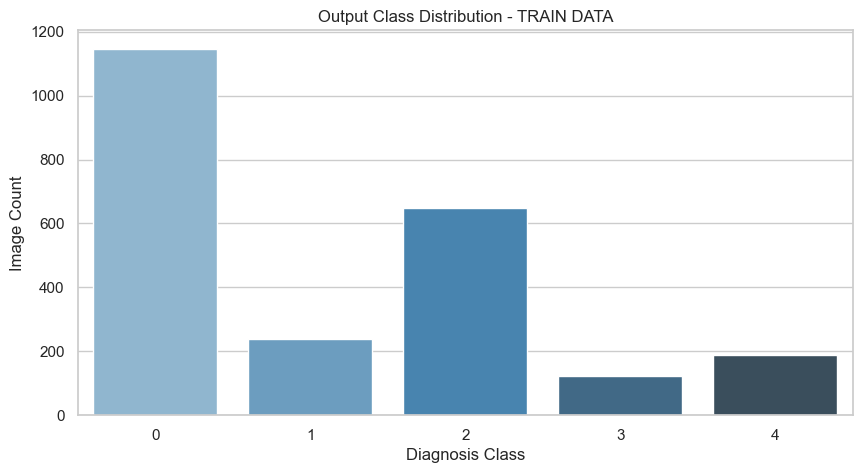

In [82]:
def plot_classes(df, title):
    df_group = pd.DataFrame(df.groupby('diagnosis').size().reset_index())
    df_group.columns = ['diagnosis', 'count']

    sns.set(rc={'figure.figsize': (10, 5)}, style='whitegrid')
    sns.barplot(x='diagnosis', y='count', data=df_group, palette="Blues_d")
    plt.title(f'Output Class Distribution - {title}')
    plt.xlabel("Diagnosis Class")
    plt.ylabel("Image Count")
    plt.show()

plot_classes(df_train_train, "TRAIN DATA")


In [84]:
with open('df_train_train.pkl', 'wb') as f:
    pickle.dump(df_train_train, f)

with open('df_train_valid.pkl', 'wb') as f:
    pickle.dump(df_train_valid, f)


In [ ]:
# Later, to load them back:
# with open('df_train_train.pkl', 'rb') as f:
#     df_train_train = pickle.load(f)

# with open('df_train_valid.pkl', 'rb') as f:
#     df_train_valid = pickle.load(f)

In [168]:
  import cv2
import numpy as np

def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if check_shape == 0:
            return img  
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def circle_crop(img, sigmaX=30):
    img = crop_image_from_gray(img)
    height, width, _ = img.shape
    x = width // 2
    y = height // 2
    r = np.amin((x, y))

    circle_img = np.zeros((height, width), np.uint8)
    cv2.circle(circle_img, (x, y), int(r), 1, thickness=-1)

    img = cv2.bitwise_and(img, img, mask=circle_img)
    img = crop_image_from_gray(img)
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigmaX), -4, 128)
    return img

def preprocess_image(path, image_size=224):
    try:
        img = cv2.imread(path)
        img = circle_crop(img)  
        img = cv2.resize(img, (image_size, image_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img
    except Exception as e:
        print(f"Failed to process {path}: {e}")
        return None


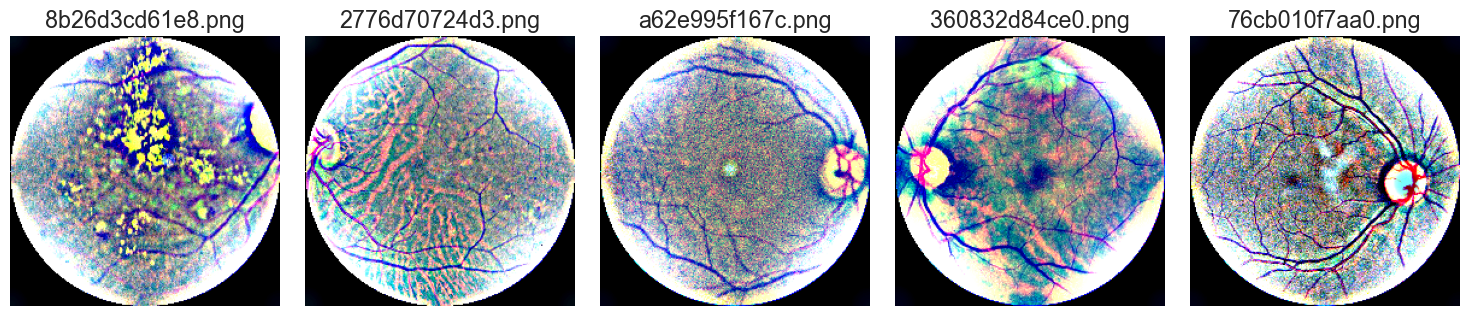

In [167]:
def show_preprocessed_images(image_dir, file_names, num_images=5):
    plt.figure(figsize=(15, 5))
    for i, file_name in enumerate(file_names[:num_images]):
        img_path = os.path.join(image_dir, file_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
        cropped_img = circle_crop(img)

        plt.subplot(1, num_images, i+1)
        plt.imshow(cropped_img)
        plt.title(file_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

sample_files = df_train_train['file_name'].tolist()
show_preprocessed_images('./train_images_resized_preprocessed', sample_files, num_images=5)

In [101]:
import os
import cv2
from tqdm import tqdm

def preprocess_and_save_images(df, image_col='file_path', save_dir='train_images_resized_preprocessed', image_size=224):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img = preprocess_image(row[image_col], image_size=image_size)
            if img is not None:
                save_path = os.path.join(save_dir, row['file_name'])
                cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        except Exception as e:
            print(f"Failed to process {row[image_col]}: {e}")


In [102]:
preprocess_and_save_images(df_train, image_col='file_path', save_dir='train_images_resized_preprocessed')

100%|████████████████████████████████████████████████████████████████████████████| 2930/2930 [1:28:53<00:00,  1.82s/it]


In [103]:
preprocess_and_save_images(df_test, image_col='file_path', save_dir='test_images_resized_preprocessed')

100%|████████████████████████████████████████████████████████████████████████████████| 366/366 [08:23<00:00,  1.37s/it]


In [110]:
IMG_SIZE = 512
BATCH_SIZE = 8
EPOCHS = 40
WARMUP_EPOCHS = 2
LEARNING_RATE = 1e-4
WARMUP_LEARNING_RATE = 1e-3
HEIGHT = 320
WIDTH = 320
CANAL = 3
N_CLASSES = df_train_train['diagnosis'].nunique()
ES_PATIENCE = 5
RLROP_PATIENCE = 3
DECAY_DROP = 0.5

In [111]:
def img_generator(train,test):
    train_datagen=ImageDataGenerator(rescale=1./255, validation_split=0.2,horizontal_flip=True)
    
    train_generator=train_datagen.flow_from_dataframe(dataframe=df_train_train,
                                                      directory="./train_images_resized_preprocessed/",
                                                      x_col="file_name",
                                                      y_col="diagnosis",
                                                      batch_size=BATCH_SIZE,
                                                      class_mode="categorical",
                                                      target_size=(HEIGHT, WIDTH),
                                                      subset='training')
    
    valid_generator=train_datagen.flow_from_dataframe(dataframe=df_train_train,
                                                      directory="./train_images_resized_preprocessed/",
                                                      x_col="file_name",
                                                      y_col="diagnosis",
                                                      batch_size=BATCH_SIZE,
                                                      class_mode="categorical",    
                                                      target_size=(HEIGHT, WIDTH),
                                                      subset='validation')
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_dataframe(dataframe=df_train_test,
                                                      directory = "./test_images_resized_preprocessed/",
                                                      x_col="file_name",
                                                      target_size=(HEIGHT, WIDTH),
                                                      batch_size=1,
                                                      shuffle=False,
                                                      class_mode=None)
    
    return train_generator,valid_generator,test_generator


In [163]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(generator, title="Sample Images", batch_index=0):
    images, labels = next(generator) if hasattr(generator, '__next__') else generator[batch_index]
   
    batch_size = images.shape[0]
    
    plt.figure(figsize=(15, 5))
    plt.suptitle(title, fontsize=16)
    
    for i in range(min(batch_size, 10)):  
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i])
        plt.axis('off')
        if labels is not None and len(labels.shape) == 2:
            plt.title(f"Label: {np.argmax(labels[i])}")
    plt.tight_layout()
    plt.show()


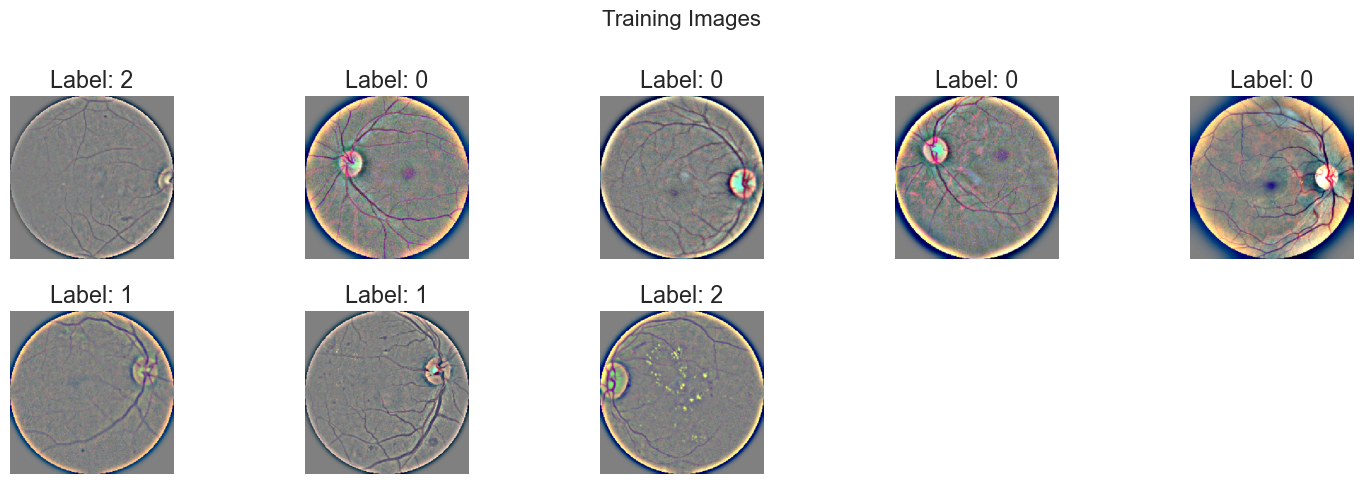

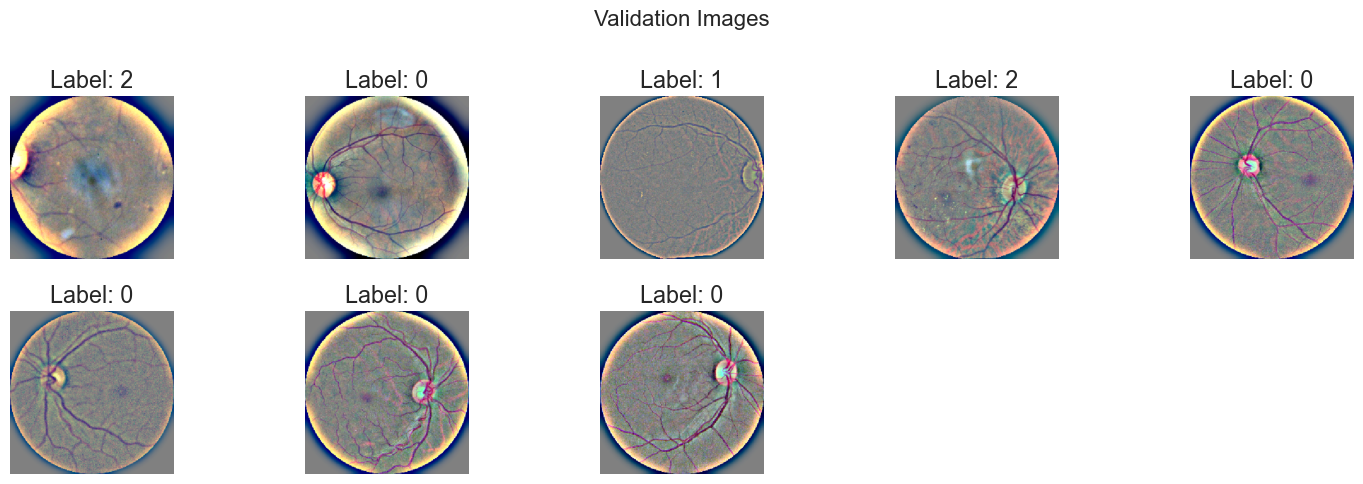

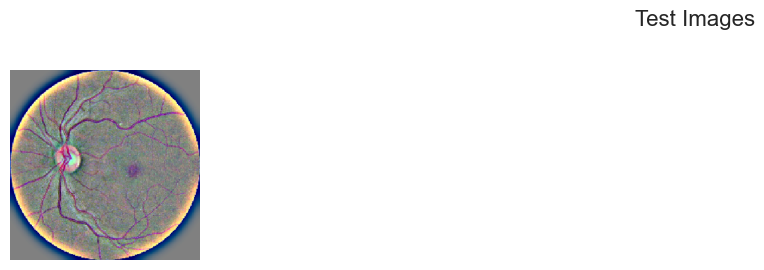

In [164]:
show_images(train_generator, title="Training Images")

show_images(valid_generator, title="Validation Images")

test_images = next(test_generator)
plt.figure(figsize=(15, 5))
plt.suptitle("Test Images", fontsize=16)
for i in range(min(len(test_images), 10)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [112]:
train_generator,valid_generator,test_generator = img_generator(df_train_train,df_train_test)

Found 1876 validated image filenames belonging to 5 classes.
Found 468 validated image filenames belonging to 5 classes.
Found 366 validated image filenames.


In [105]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(df_train_train['diagnosis'])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_train_train['diagnosis'])

# Convert to dictionary
class_weights_dict = {i : class_weights[i] for i in range(len(classes))}
print("Class Weights:", class_weights_dict)


Class Weights: {0: 0.40871839581517, 1: 1.9533333333333334, 2: 0.7245749613601237, 3: 3.8113821138211383, 4: 2.506951871657754}


In [115]:
import keras
keras.utils.get_file(
    'resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
    'https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
    cache_subdir='models',
    cache_dir='.'
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


'.\\models\\resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'

In [118]:
def create_model(input_shape, n_out):
    input_tensor = Input(shape=input_shape)
    
    base_model = applications.ResNet50(weights=None, include_top=False, input_tensor=input_tensor)
    
    # Load weights from the downloaded file
    base_model.load_weights('./models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5')

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    final_output = Dense(n_out, activation='softmax', name='final_output')(x)

    model = Model(input_tensor, final_output)
    return model


In [119]:
model = create_model(input_shape=(HEIGHT, WIDTH, CANAL), n_out=N_CLASSES)

for layer in model.layers:
    layer.trainable = False

for i in range(-5, 0):
    model.layers[i].trainable = True
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 320, 320, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 326, 326, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 160, 160, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 160, 160, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 160, 160, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 162, 162, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 80, 80, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 80, 80, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 80, 80, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 80, 80, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 80, 80, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 80, 80, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 80, 80, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 80, 80, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 80, 80, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 27,794,309 (106.03 MB)

 Trainable params: 4,206,597 (16.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [120]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size
print(STEP_SIZE_TRAIN,STEP_SIZE_VALID)

234 58


In [123]:
# model.compile(optimizer = optimizers.Adam(learning_rate=WARMUP_LEARNING_RATE),loss = 'categorical_crossentropy',metrics = ['accuracy'])

# history_warmup = model.fit_generator(generator=train_generator,
#                                      steps_per_epoch=STEP_SIZE_TRAIN,
#                                      validation_data=valid_generator,validation_steps=STEP_SIZE_VALID,
#                                      epochs=WARMUP_EPOCHS,
#                                      verbose=1).history
model.compile(
    optimizer=optimizers.Adam(learning_rate=WARMUP_LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_warmup = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=valid_generator,
    validation_steps=STEP_SIZE_VALID,
    epochs=WARMUP_EPOCHS,
    verbose=1
).history


Epoch 1/2
234/234 ━━━━━━━━━━━━━━━━━━━━ 635s 3s/step - accuracy: 0.3820 - loss: 2.5344 - val_accuracy: 0.4892 - val_loss: 1.2521
Epoch 2/2
234/234 ━━━━━━━━━━━━━━━━━━━━ 122s 513ms/step - accuracy: 0.5000 - loss: 1.4606 - val_accuracy: 0.4871 - val_loss: 1.3023


In [125]:
for layer in model.layers:
    layer.trainable = True

es = EarlyStopping(monitor='val_loss', mode='min', patience=ES_PATIENCE, restore_best_weights=True, verbose=1)
rlrop = ReduceLROnPlateau(monitor='val_loss', mode='min', patience=RLROP_PATIENCE, factor=DECAY_DROP, min_lr=1e-6, verbose=1)

callback_list = [es, rlrop]
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss="binary_crossentropy",  metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 320, 320, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 326, 326, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 160, 160, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 160, 160, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 160, 160, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 162, 162, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 80, 80, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 80, 80, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 80, 80, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 80, 80, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 80, 80, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 80, 80, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 80, 80, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 80, 80, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 80, 80, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 27,794,309 (106.03 MB)

 Trainable params: 27,741,189 (105.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [127]:
history_finetunning = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=valid_generator,
    validation_steps=STEP_SIZE_VALID,
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=1
).history


Epoch 1/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2764s 11s/step - accuracy: 0.6297 - loss: 0.5282 - val_accuracy: 0.2845 - val_loss: 0.4748 - learning_rate: 1.0000e-04
Epoch 2/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 168s 673ms/step - accuracy: 0.7500 - loss: 0.2787 - val_accuracy: 0.2953 - val_loss: 0.4685 - learning_rate: 1.0000e-04
Epoch 3/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2592s 11s/step - accuracy: 0.7305 - loss: 0.2370 - val_accuracy: 0.5668 - val_loss: 0.4106 - learning_rate: 1.0000e-04
Epoch 4/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 146s 581ms/step - accuracy: 0.5000 - loss: 0.4448 - val_accuracy: 0.5065 - val_loss: 0.4156 - learning_rate: 1.0000e-04
Epoch 5/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2585s 11s/step - accuracy: 0.7761 - loss: 0.2103 - val_accuracy: 0.6315 - val_loss: 0.3331 - learning_rate: 1.0000e-04
Epoch 6/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 167s 671ms/step - accuracy: 0.8750 - loss: 0.1849 - val_accuracy: 0.6293 - val_loss: 0.3273 - learning_rate: 1.0000e-04
Epoch 7/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 260

In [129]:
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed


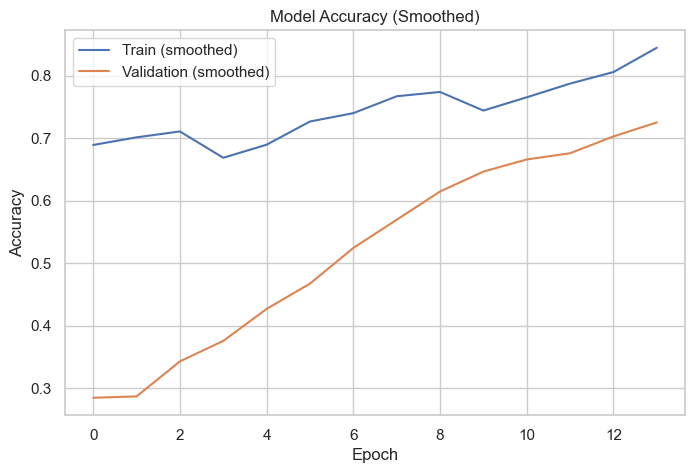

In [130]:
plt.figure(figsize=(8, 5))

# Smooth training and validation accuracy
acc = smooth_curve(history_finetunning['accuracy'])
val_acc = smooth_curve(history_finetunning['val_accuracy'])

plt.plot(acc, label='Train (smoothed)')
plt.plot(val_acc, label='Validation (smoothed)')
plt.title('Model Accuracy (Smoothed)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.gca().ticklabel_format(axis='both', style='plain', useOffset=False)
plt.show()


In [132]:
complete_datagen = ImageDataGenerator(rescale=1./255)
complete_generator = complete_datagen.flow_from_dataframe(dataframe=df_train_train,
                                                          directory = "./train_images_resized_preprocessed/",
                                                          x_col="file_name",
                                                          target_size=(HEIGHT, WIDTH),
                                                          batch_size=1,
                                                          shuffle=False,
                                                          class_mode=None)

STEP_SIZE_COMPLETE = complete_generator.n//complete_generator.batch_size
train_preds = model.predict(complete_generator, steps=STEP_SIZE_COMPLETE,verbose = 1)
train_preds = [np.argmax(pred) for pred in train_preds]

Found 2344 validated image filenames.
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 1160s 492ms/step


In [137]:
import numpy as np
from sklearn.metrics import accuracy_score

print("Train Accuracy score : %.3f" % accuracy_score(df_train_train['diagnosis'].astype('int'),train_preds))

Train Accuracy score : 0.858


In [140]:
test_generator.reset()
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size

# Use model.predict, not model.generator
test_preds = model.predict(test_generator, steps=STEP_SIZE_TEST, verbose=1)

# Convert softmax predictions to class labels
test_labels = np.argmax(test_preds, axis=1)


366/366 ━━━━━━━━━━━━━━━━━━━━ 180s 491ms/step


In [141]:
def plot_conf_matrix(true,pred,classes):
    cf = confusion_matrix(true, pred)
    
    df_cm = pd.DataFrame(cf, range(len(classes)), range(len(classes)))
    plt.figure(figsize=(8,5.5))
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16},xticklabels = classes ,yticklabels = classes,fmt='g')
    #sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix


In [145]:
print("Test Accuracy score : %.3f" % accuracy_score(df_train_test['diagnosis'].astype('int'),test_labels))

Test Accuracy score : 0.817


In [146]:
x = PrettyTable()
x.field_names = ["S.No.","ResNet50 Model","Image Processing","Data Augmentation","Hyperparameters(BS,Opt,lr,ep)","Train QWK","Test QWK"]

x.add_row([1,"R-P-D-p(0.5)-D-p(0.5)-S(5)","--","Hor Flip,Scale 1/255","(4,'Adam','1e-4',7)","0.912","0.905"])
x.add_row([2,"R-P-D-p(0.5)-D-p(0.5)-S(5)","Circle Crop, Gaussian Blur","Hor Flip,Scale 1/255","(4,'Adam','1e-4',7)","0.98","0.904"])

print(x)

+-------+----------------------------+----------------------------+----------------------+-------------------------------+-----------+----------+
| S.No. |       ResNet50 Model       |      Image Processing      |  Data Augmentation   | Hyperparameters(BS,Opt,lr,ep) | Train QWK | Test QWK |
+-------+----------------------------+----------------------------+----------------------+-------------------------------+-----------+----------+
|   1   | R-P-D-p(0.5)-D-p(0.5)-S(5) |             --             | Hor Flip,Scale 1/255 |      (4,'Adam','1e-4',7)      |   0.912   |  0.905   |
|   2   | R-P-D-p(0.5)-D-p(0.5)-S(5) | Circle Crop, Gaussian Blur | Hor Flip,Scale 1/255 |      (4,'Adam','1e-4',7)      |    0.98   |  0.904   |
+-------+----------------------------+----------------------------+----------------------+-------------------------------+-----------+----------+


In [151]:
model.save("model_dr_multiclass.keras") 
